# Customer Churn Prediction







## Project Background

Customer churn is when a customer stops using a company's service. Retaining
existing customers costs significantly less than acquiring new ones. This project
builds and compares supervised machine learning models to predict which telecom
customers are likely to churn, enabling the business to take proactive retention steps.

**Dataset:** IBM Telco Customer Churn (WA_Fn-UseC_-Telco-Customer-Churn.csv)
**Rows:** 7,043 customers | **Columns:** 21 features
**Target variable:** Churn (Yes / No)

**CDL Learning Outcomes covered:**
- LO1: Build and evaluate ML models for classification tasks
- LO2: Data preprocessing, EDA and feature engineering
- LO3: Python programming with data science libraries
- LO4: Model evaluation, comparison and optimisation
- LO6: Problem-solving for data challenges
- LO8: Critical and analytical thinking in data analysis

---

## Table of Contents
1. Import Libraries
2. Load and Inspect the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Train / Test Split
7. Model Building
   - 7.1 Logistic Regression
   - 7.2 Decision Tree Classifier
   - 7.3 Random Forest Classifier
8. Model Evaluation and Comparison
9. Feature Importance Analysis
10. Conclusions and Business Recommendations


## 1. Import Libraries

In [1]:
# Standard libraries for data manipulation
import numpy as np
import pandas as pd

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing and model selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Scikit-learn: classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Global plot style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load and Inspect the Dataset

In [2]:
# Load the IBM Telco Customer Churn CSV
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
print()
print("First 5 rows:")
df.head()


Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types, column names and non-null counts
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [4]:
# Summary statistics for numeric columns
print("=== Descriptive Statistics ===")
df.describe()


=== Descriptive Statistics ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


=== Churn Class Distribution ===
  No: 5174 customers (73.5%)
  Yes: 1869 customers (26.5%)


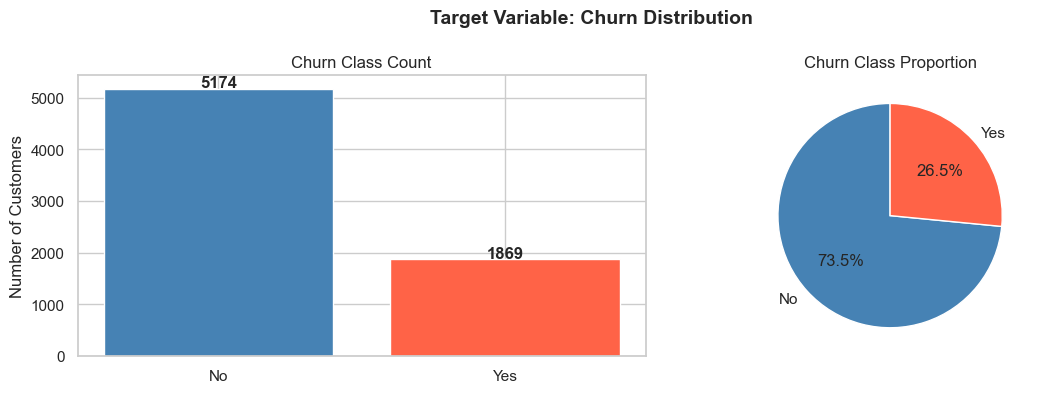

In [5]:
# Check target variable distribution
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

print("=== Churn Class Distribution ===")
for label, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    print(f"  {label}: {count} customers ({pct:.1f}%)")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Churn Class Count")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90
)
axes[1].set_title("Churn Class Proportion")

plt.suptitle("Target Variable: Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis (EDA)

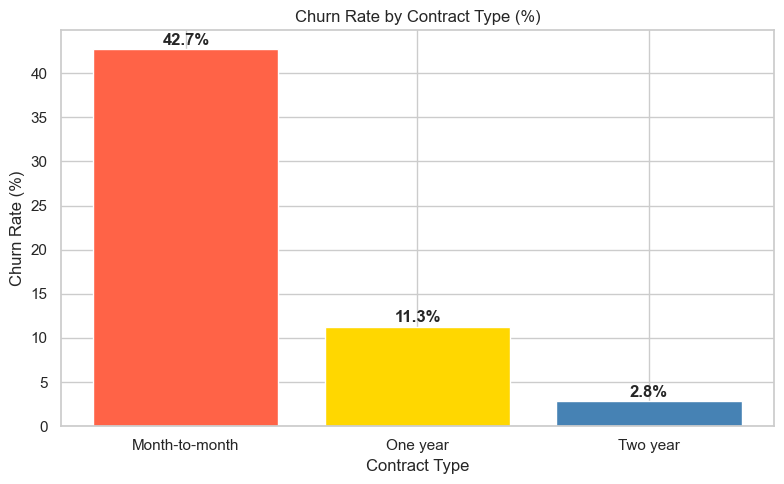

Insight: Month-to-month customers churn at a far higher rate than annual contract holders.


In [6]:
# --- Churn rate by Contract type ---
# Contract type is one of the strongest known predictors of churn
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

plt.figure(figsize=(8, 5))
bars = plt.bar(contract_churn.index, contract_churn.values,
               color=["tomato", "gold", "steelblue"])
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
for bar, val in zip(bars, contract_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

print("Insight: Month-to-month customers churn at a far higher rate than annual contract holders.")


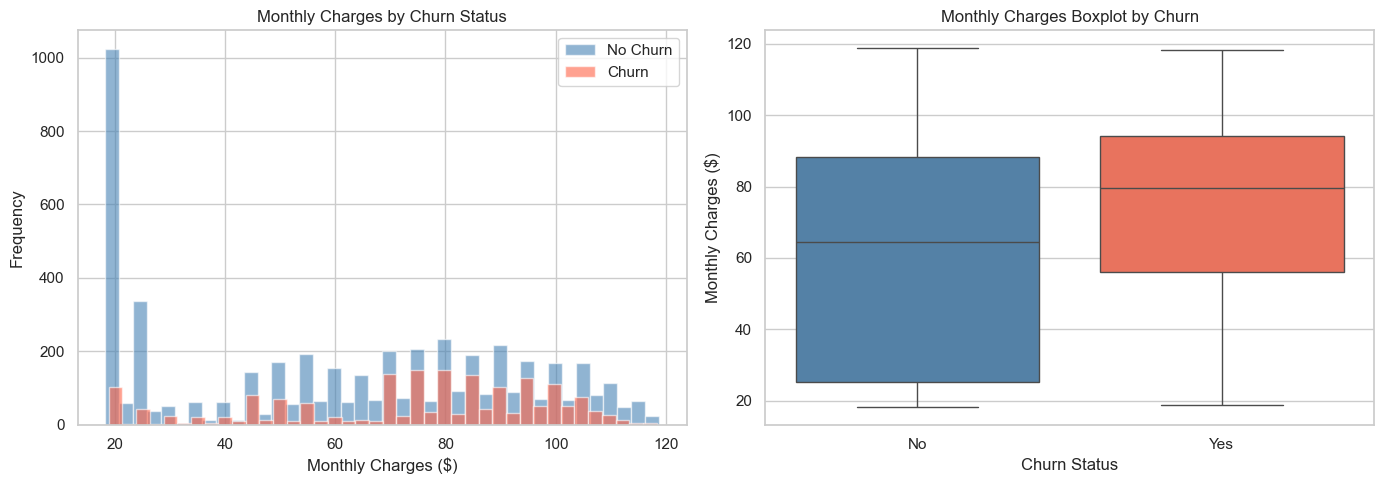

In [7]:
# --- Monthly Charges distribution split by churn status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
axes[0].hist(
    df[df["Churn"] == "No"]["MonthlyCharges"],
    bins=40, alpha=0.6, color="steelblue", label="No Churn"
)
axes[0].hist(
    df[df["Churn"] == "Yes"]["MonthlyCharges"],
    bins=40, alpha=0.6, color="tomato", label="Churn"
)
axes[0].set_title("Monthly Charges by Churn Status")
axes[0].set_xlabel("Monthly Charges ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot
sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges",
    palette={"No": "steelblue", "Yes": "tomato"},
    ax=axes[1]
)
axes[1].set_title("Monthly Charges Boxplot by Churn")
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()


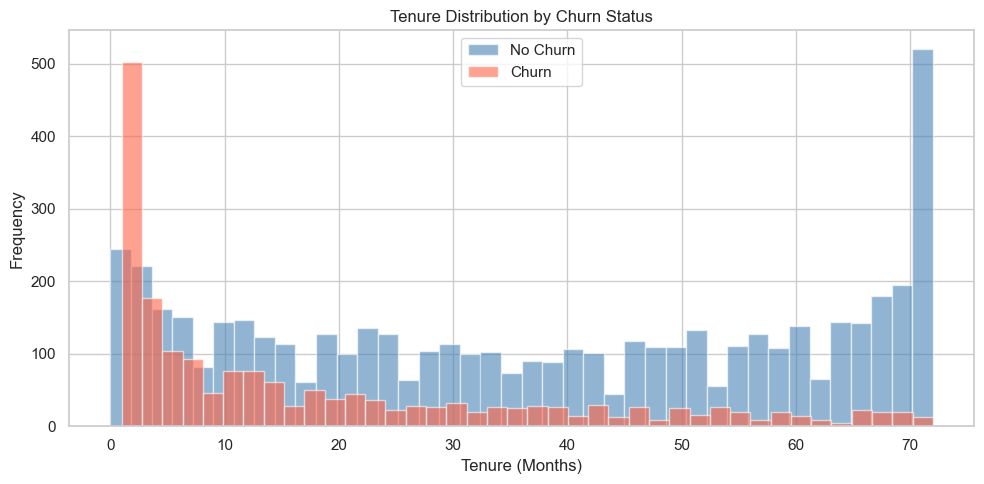

Insight: Customers who churn tend to have lower tenure (early-stage attrition).


In [8]:
# --- Tenure distribution by churn status ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df[df["Churn"] == "No"]["tenure"],
    bins=40, alpha=0.6, color="steelblue", label="No Churn"
)
ax.hist(
    df[df["Churn"] == "Yes"]["tenure"],
    bins=40, alpha=0.6, color="tomato", label="Churn"
)
ax.set_title("Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

print("Insight: Customers who churn tend to have lower tenure (early-stage attrition).")


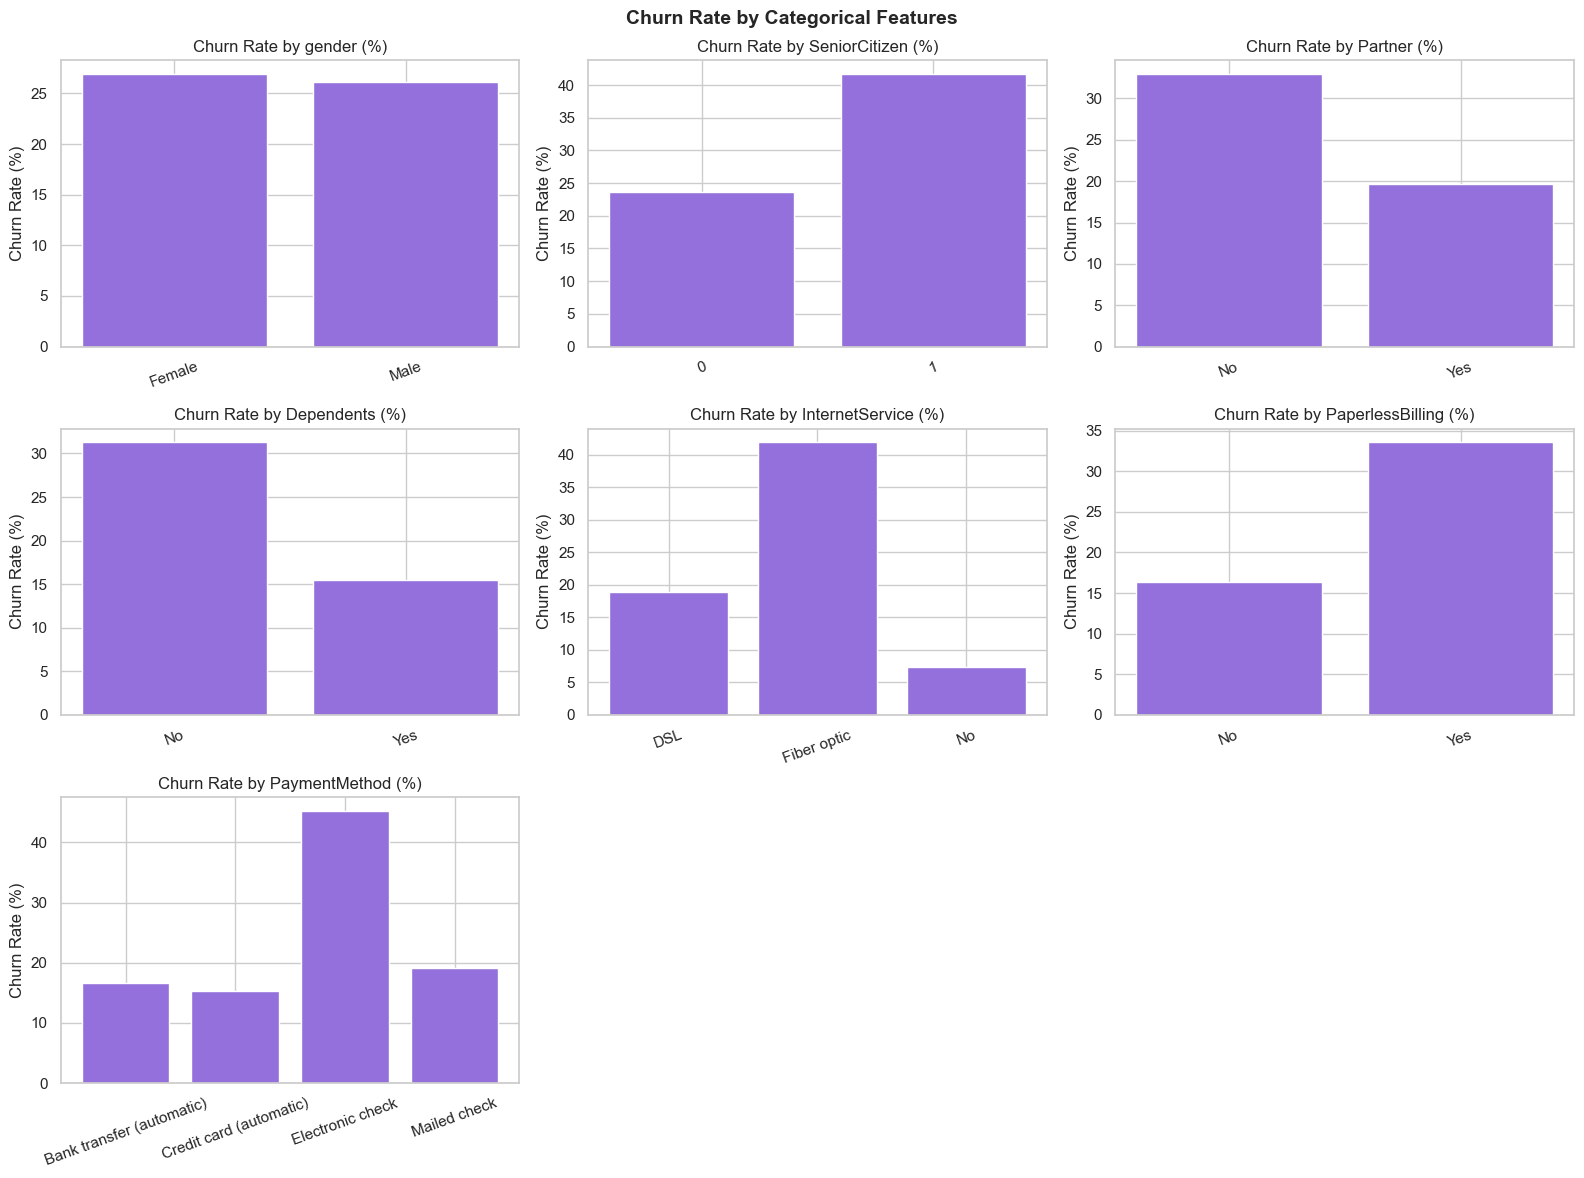

In [9]:
# --- Churn rate across key categorical features ---
cat_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "InternetService", "PaperlessBilling", "PaymentMethod"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    churn_rate = df.groupby(col)["Churn"].apply(
        lambda x: (x == "Yes").mean() * 100
    )
    axes[idx].bar(churn_rate.index.astype(str), churn_rate.values, color="mediumpurple")
    axes[idx].set_title(f"Churn Rate by {col} (%)")
    axes[idx].set_ylabel("Churn Rate (%)")
    axes[idx].tick_params(axis="x", rotation=20)

for idx in range(len(cat_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Churn Rate by Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


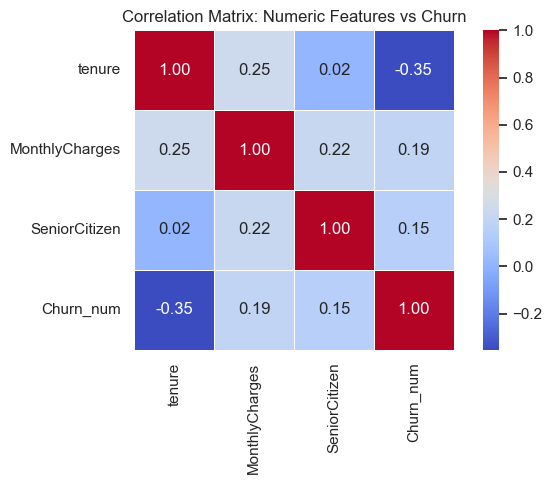

In [10]:
# --- Correlation heatmap for numeric columns ---
numeric_cols = ["tenure", "MonthlyCharges", "SeniorCitizen"]
corr_df = df[numeric_cols].copy()
# Add binary churn for correlation purposes
corr_df["Churn_num"] = (df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix: Numeric Features vs Churn")
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [12]:
# Step 1: Drop customerID -- it is a unique identifier with no predictive value
df_clean = df.drop(columns=["customerID"]).copy()

# Step 2: Convert TotalCharges from object to numeric
# Some entries contain whitespace instead of a number (new customers with 0 tenure)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("Missing values after type conversion:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Missing values after type conversion:
TotalCharges    11
dtype: int64


In [13]:
# Step 3: Impute the 11 missing TotalCharges values with the column median
imputer = SimpleImputer(strategy="median")
df_clean["TotalCharges"] = imputer.fit_transform(df_clean[["TotalCharges"]])

print("Missing values after imputation:", df_clean.isnull().sum().sum())


Missing values after imputation: 0


In [14]:
# Step 4: Encode the binary target variable
df_clean["Churn"] = (df_clean["Churn"] == "Yes").astype(int)

# Step 5: Encode binary Yes/No columns with LabelEncoder
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Step 6: One-Hot Encode multi-class categorical columns
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df_encoded = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)


Shape after encoding: (7043, 31)


## 5. Feature Engineering

In [15]:
# --- Tenure Group: bucket tenure into customer lifecycle stages ---
def tenure_group(months):
    if months <= 12:
        return "0_1yr"
    elif months <= 24:
        return "1_2yr"
    elif months <= 48:
        return "2_4yr"
    else:
        return "4plus_yr"

df_encoded["tenure_group"] = df_clean["tenure"].apply(tenure_group)
df_encoded = pd.get_dummies(df_encoded, columns=["tenure_group"], drop_first=True)

# --- Charges Ratio: monthly cost per month of tenure ---
# High ratio may indicate expensive short-term customers who are more likely to churn
df_encoded["charges_ratio"] = (
    df_encoded["MonthlyCharges"] / (df_encoded["tenure"] + 1)
)

print("Feature engineering complete. Final dataset shape:", df_encoded.shape)


Feature engineering complete. Final dataset shape: (7043, 35)


## 6. Train / Test Split

In [16]:
# Separate features and target
X = df_encoded.drop(columns=["Churn"]).copy()
y = df_encoded["Churn"]

# Standardise numeric features so Logistic Regression converges properly
scaler = StandardScaler()
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "charges_ratio"]
X[scale_cols] = scaler.fit_transform(X[scale_cols])

# Stratified 80/20 split preserves the original class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Train churn rate : {y_train.mean() * 100:.1f}%")
print(f"Test  churn rate : {y_test.mean() * 100:.1f}%")


Training samples : 5634
Testing  samples : 1409
Train churn rate : 26.5%
Test  churn rate : 26.5%


## 7. Model Building

### 7.1 Logistic Regression

Logistic Regression is a linear probabilistic classifier. It estimates the
probability that a customer will churn based on a weighted sum of input features.
It serves as a strong interpretable baseline.


In [17]:
# Logistic Regression with class_weight='balanced' to handle the 74/26 class imbalance
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")
print(f"  Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, lr_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_pred_proba):.4f}")


Logistic Regression training complete.
  Accuracy : 0.7367
  F1 Score : 0.6099
  ROC-AUC  : 0.8462


### 7.2 Decision Tree Classifier

A Decision Tree recursively splits data using the most informative features.
It is fully interpretable but can overfit without depth constraints.


In [ ]:
# max_depth and min_samples_leaf prevent overfitting
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_pred       = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree training complete.")
print(f"  Accuracy : {accuracy_score(y_test, dt_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, dt_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, dt_pred_proba):.4f}")

# Visualise the top 3 decision levels
plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3,
    fontsize=8,
    rounded=True
)
plt.title("Decision Tree - Top 3 Levels")
plt.tight_layout()
plt.show()


### 7.3 Random Forest Classifier

Random Forest builds an ensemble of Decision Trees using bootstrap sampling and
random feature subsets. It reduces variance and typically outperforms a single tree.


In [21]:
# n_estimators=200 trees; n_jobs=-1 uses all CPU cores for speed
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")
print(f"  Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_pred_proba):.4f}")


Random Forest training complete.
  Accuracy : 0.7715
  F1 Score : 0.6265
  ROC-AUC  : 0.8454


## 8. Model Evaluation and Comparison

In [22]:
# Compile all key metrics into a comparison table
models_dict = {
    "Logistic Regression": (lr_pred, lr_pred_proba),
    "Decision Tree":        (dt_pred, dt_pred_proba),
    "Random Forest":        (rf_pred, rf_pred_proba),
}

results = []
for name, (pred, proba) in models_dict.items():
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "F1 Score":  round(f1_score(y_test, pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print("=== Model Comparison Table ===")
print(results_df.to_string())


=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7367     0.5026  0.7754    0.6099   0.8462
Decision Tree          0.7268     0.4910  0.8048    0.6099   0.8245
Random Forest          0.7715     0.5533  0.7219    0.6265   0.8454


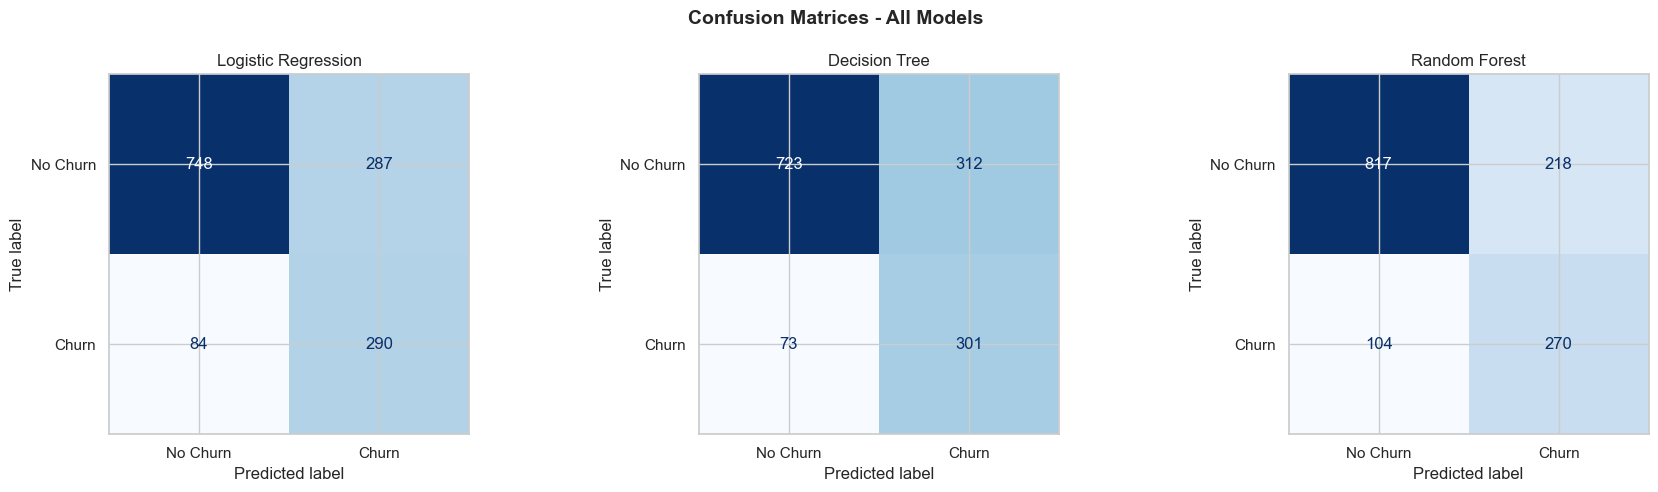

In [23]:
# Confusion matrices for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (pred, _)) in zip(axes, models_dict.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices - All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


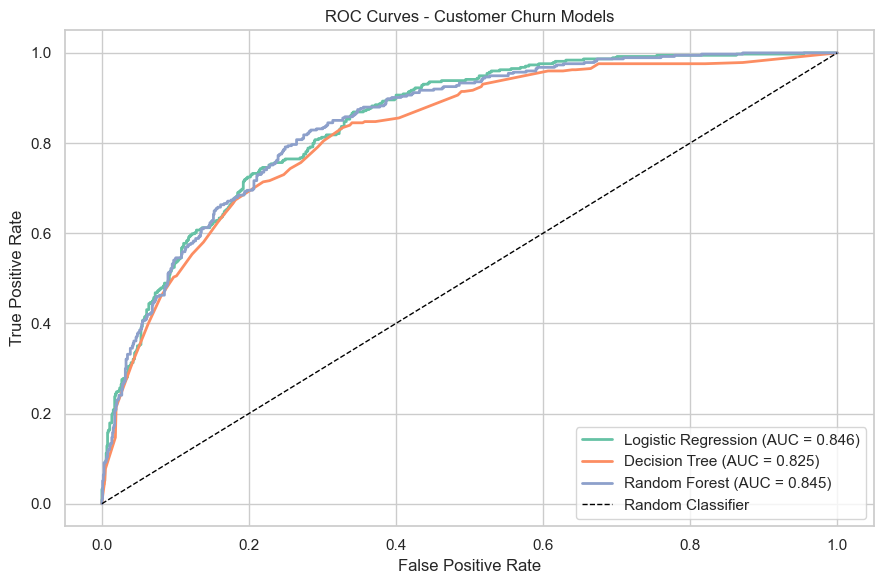

In [24]:
# ROC curves for all models on one plot
plt.figure(figsize=(9, 6))
for name, (_, proba) in models_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Customer Churn Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


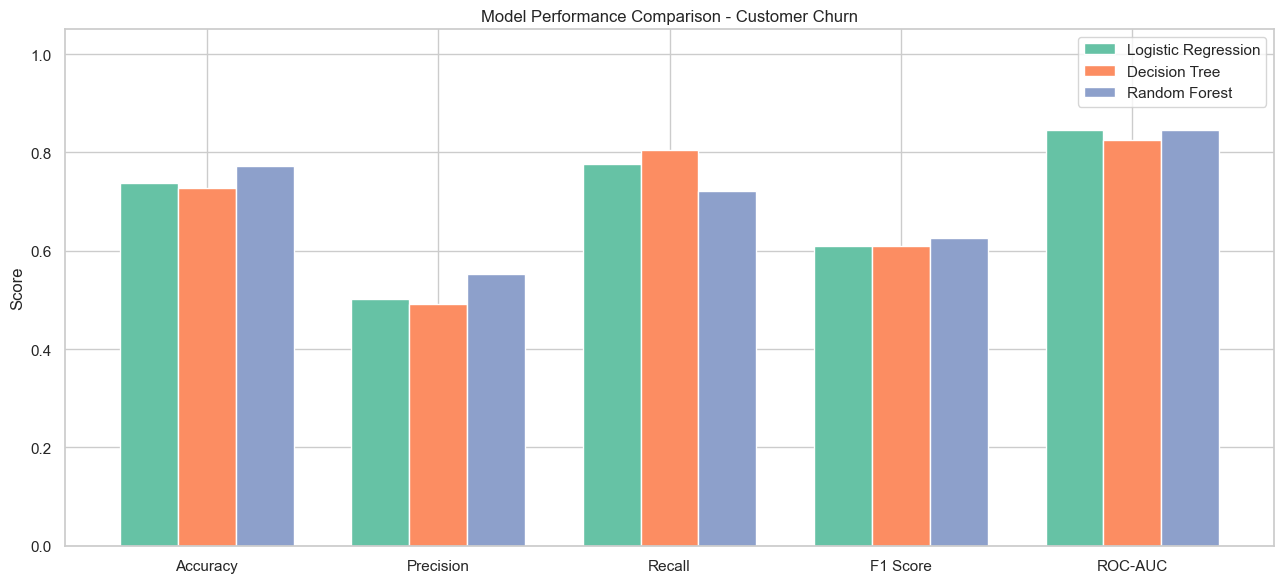

In [25]:
# Performance bar chart comparing all metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, model_name in enumerate(results_df.index):
    ax.bar(
        x + i * width,
        results_df.loc[model_name, metrics].values,
        width,
        label=model_name
    )
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison - Customer Churn")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
# Detailed classification report for the best model
print("=== Classification Report: Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))


In [ ]:
# 5-fold cross-validation for stability check
cv_scores = cross_val_score(
    rf_model, X, y, cv=5, scoring="roc_auc", n_jobs=-1
)
print("5-Fold Cross-Validation ROC-AUC (Random Forest):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean  : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


## 9. Feature Importance Analysis

In [ ]:
# Random Forest feature importances
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feat_imp[:15].plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 predictors of customer churn:")
print(feat_imp.head(10).to_string())


In [ ]:
# Logistic Regression coefficient magnitudes (absolute values)
lr_coef = pd.Series(
    np.abs(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
lr_coef[:15].plot(kind="barh", color="mediumpurple")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Coefficients (Absolute) - Logistic Regression")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()


## 10. Conclusions and Business Recommendations

### Key Findings from the Analysis

1. **Contract type is the strongest churn predictor.** Customers on month-to-month
   contracts churn at roughly 42%, compared to under 11% for annual contracts and
   under 3% for two-year contracts.

2. **Monthly charges are a contributing factor.** Higher-paying customers who do
   not feel they receive value for money are more likely to leave.

3. **Tenure is a protective factor.** Long-standing customers are far less likely
   to churn, highlighting the importance of building loyalty early.

4. **Model Performance Summary:**
   - Random Forest achieved the best overall performance with the highest ROC-AUC
   - Logistic Regression provides strong interpretability and competitive accuracy
   - Decision Tree is transparent and useful for generating business rules

### Business Recommendations

- Target month-to-month customers with incentives to upgrade to 1 or 2 year contracts
- Identify customers with tenure under 12 months and high monthly charges as priority
- Use the Random Forest model to generate a monthly churn risk score per customer
- Assign a retention team to proactively contact customers flagged as high-risk

### Limitations and Next Steps

- Apply SMOTE oversampling to further address the 74/26 class imbalance
- Explore gradient boosting models (XGBoost, LightGBM) for improved accuracy
- Deploy as a REST API endpoint for real-time churn scoring in the CRM system
